In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module= 'openpyxl')
import missingno as msno

In [31]:
location = r"C:\Users\rajeshkumar.t\Downloads\Repeat_ML.csv"
df1 = pd.read_csv(location, low_memory =False)
#df= df1[df1['total_repeat_issue_calls']<40000].copy()

print(df.columns)

Index(['Month_num', 'analytic_business_unit', 'primary_reason',
       'delivered_gmv', 'cancelled_gmv', 'returned_gmv', 'total_taxn',
       'cancelled_txn_count', 'returned_txn_count', 'Delivered_txn_count',
       'pre_breach_calls', 'post_breach_calls', 'total_repeat_issue_calls',
       'total_month_rev', 'prev_month_rev', 'month_revenue_growth_pct'],
      dtype='object')


<Figure size 1000x500 with 0 Axes>

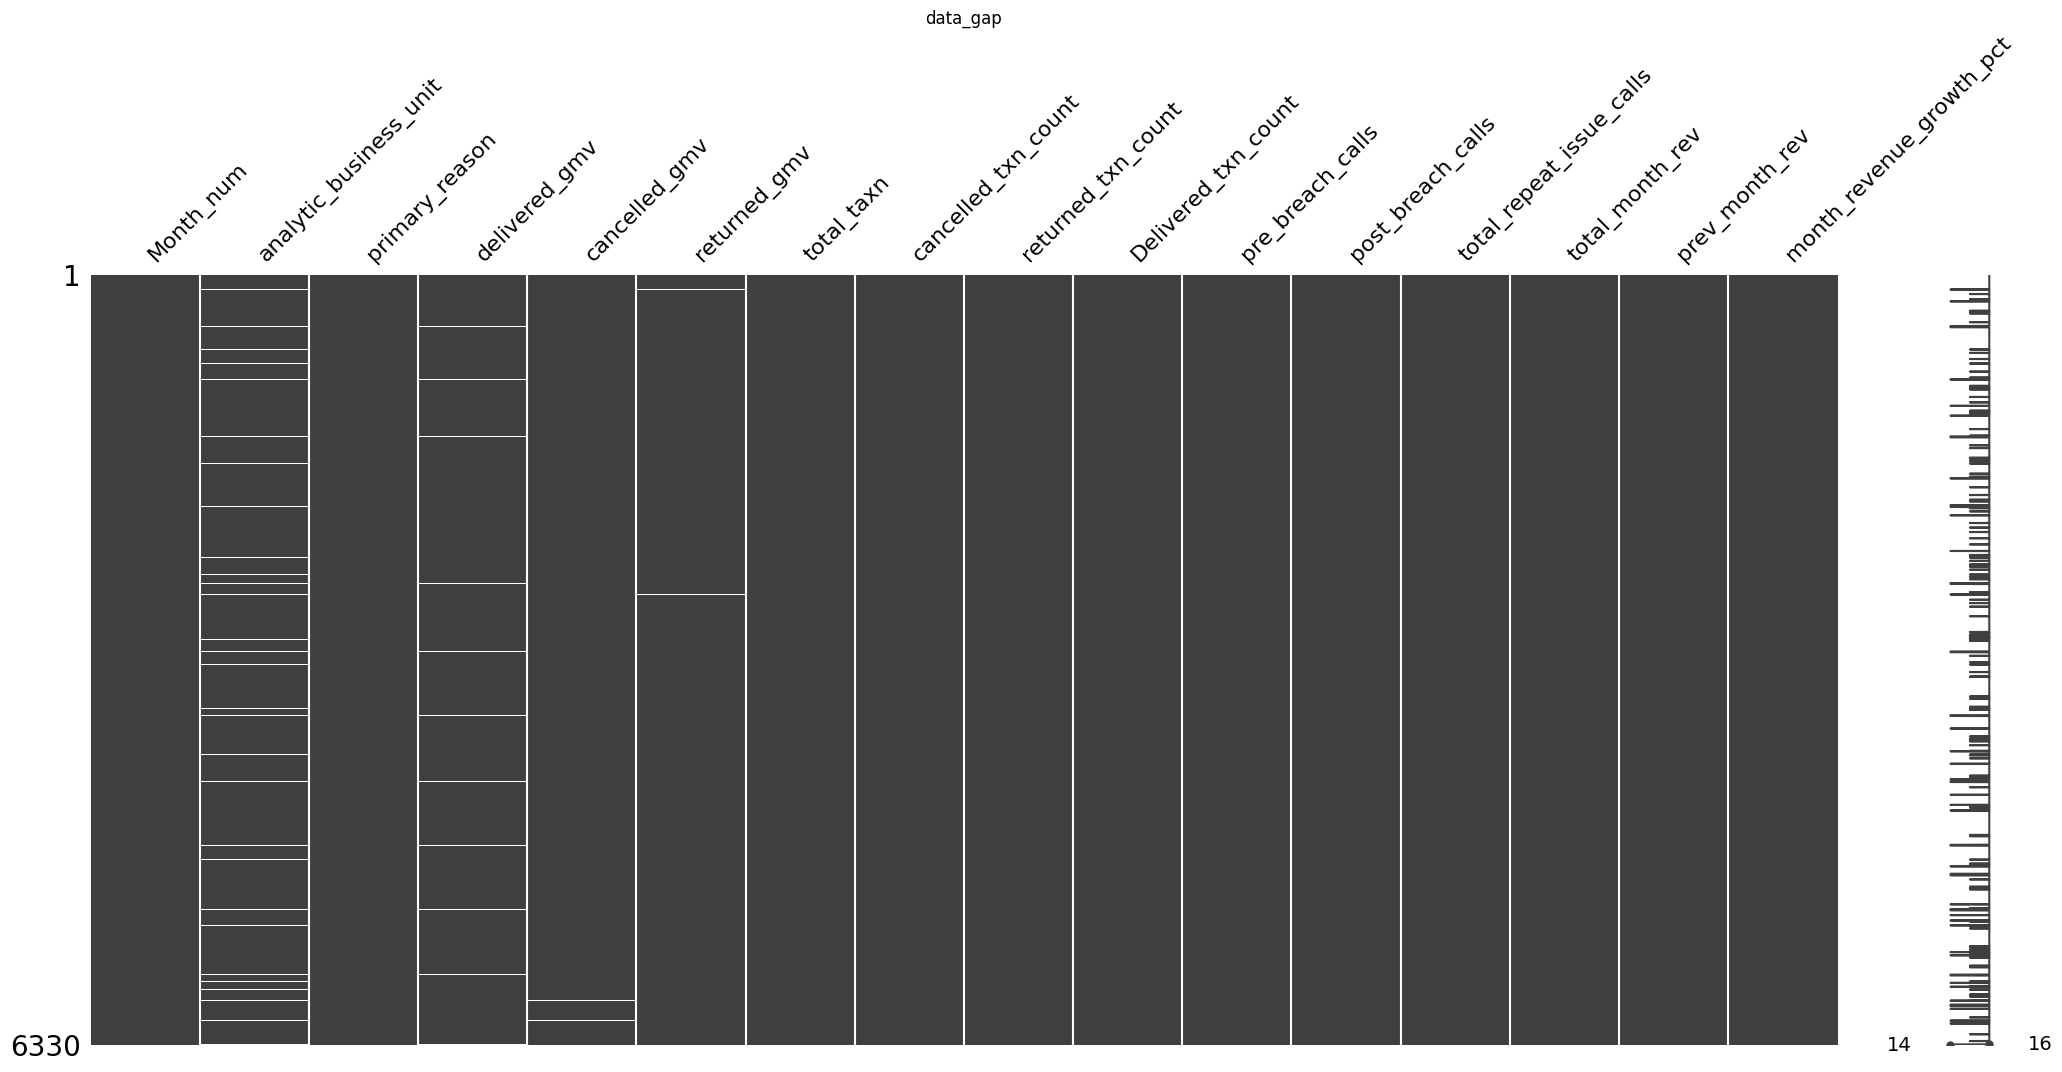

In [32]:
plt.figure(figsize=(10,5))
msno.matrix(df)
plt.title('data_gap')
plt.show()

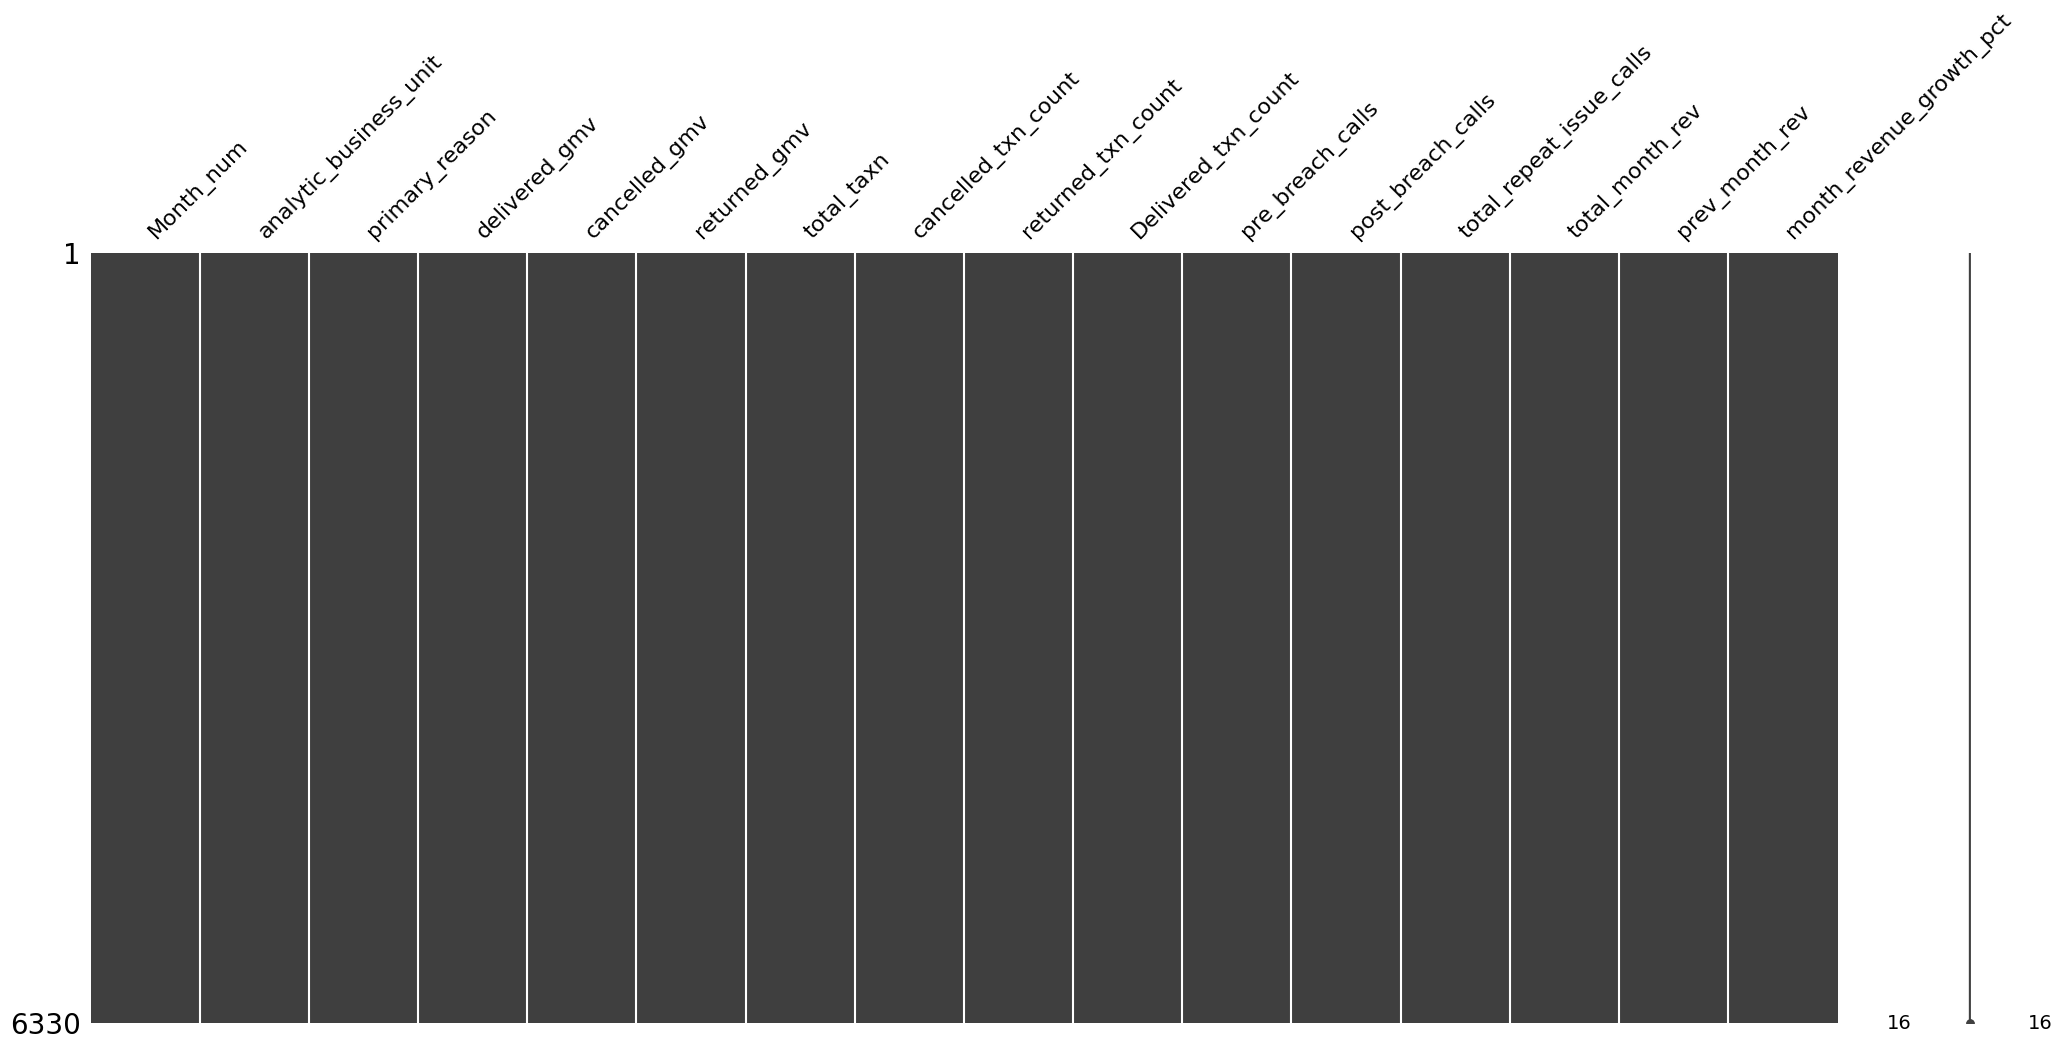

In [33]:

#print(df.dtypes)
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] =df[num_cols].fillna(0)
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols]=df[cat_cols].fillna('unknown')

msno.matrix(df)
plt.show()

In [20]:
le_bu =LabelEncoder()
df['bu_id'] = le_bu.fit_transform(df['analytic_business_unit'].astype(str))

reason_freq = df['primary_reason'].value_counts()
df['reason_rank'] = df['primary_reason'].map(reason_freq)



In [21]:
print(f"Total_Delivered_GMV     :${df['delivered_gmv'].sum():,.2f}")
print(f"Total Repeat Calls      :{int(df['total_repeat_issue_calls'].sum()):,}")
print(f"Total Transactions      :{int(df['total_transaction'].sum()):,}")
      
      

Total_Delivered_GMV     :$700,443,609.00
Total Repeat Calls      :9,349,228
Total Transactions      :8,266,019


In [131]:
overall_percentage = (df['total_repeat_issue_calls'].sum()/df['total_transaction'].sum()) *100
print(f"overall_percentage :{overall_percentage:.2f}")

overall_percentage :85.93


In [132]:
features = ['delivered_gmv', 'cancelled_gmv', 'returned_gmv', 'total_transaction',
       'cancelled_transaction', 'returned_transaction',
       'Delivered_transaction', 'pre_breach_calls', 'post_breach_calls',
        'total_month_rev','bu_id','reason_rank']
X = df[features]
y= df['total_repeat_issue_calls']

#Random
X_train, X_test, y_train, y_test =train_test_split(X,y, test_size=0.2, random_state = 42)
model_rf = RandomForestRegressor(n_estimators = 200, max_depth = 15, random_state = 42)
model_rf.fit(X_train,y_train)
rf_pred = model_rf.predict(X_test)

#XGBoost
model_xgb = XGBRegressor(n_estimators = 200, learning_rate = 0.05, max_depth =6, random_state = 42)
model_xgb.fit(X_train, y_train)
xgb_pred = model_xgb.predict(X_test)

def print_metrics(actual, pred, name):
    r2 =r2_score(actual, pred)
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    print(f"\n--- {name} Performance ----")
    print(f"R-Squared Accuracy :{r2*100:.2f}%")
    print(f"Mean Absolute Error :{mae:.2f} calls")
    print(f"Root Mean Sq. Error :{rmse:.2f}")

print_metrics(y_test, rf_pred, "RANDOM_FOREST")
print_metrics(y_test,xgb_pred, "XGBOOST")

importance  =pd.DataFrame({
    'Feature': features,
    'Weight': (model_rf.feature_importances_ + model_xgb.feature_importances_) / 2
}).sort_values('Weight', ascending=False)

print("\n---  ML INFERENCE: ---")
print(importance.head(5))

##Isolation_forest
iso = IsolationForest(contamination =0.03, random_state = 42)
df['risk_zone'] = iso.fit_predict(X)
print(f"\n--- ANOMALY DECTION--- ")
print(f"Flagged {len(df[df['risk_zone'] == -1])} high risk rows for immediate audit")

## K-Mean

bu_summary = df.groupby('analytic_business_unit').agg({
    'total_repeat_issue_calls': 'sum',
    'total_transaction': 'sum'
})
bu_summary['friction_score'] = bu_summary['total_repeat_issue_calls'] / bu_summary['total_transaction'].replace(0,1)

scaler = StandardScaler()
scaled_friction = scaler.fit_transform(bu_summary[['friction_score']])
kmeans = KMeans(n_clusters=3, random_state = 42).fit(scaled_friction)
bu_summary['Cluster'] = kmeans.labels_

status_map = {
    0: "Healthy: Low Friction",
    1: "At Risk: High Resolution Loop",
    2: "Crisis: Major Friction Failure"
}
bu_summary['Status'] = bu_summary['Cluster'].map(status_map)

print("\n-- TOP 5 Buisness Head---")
print(bu_summary[['Status','Cluster']].sort_values('Cluster', ascending=False).head(5))

output_path = r"C:\Users\rajeshkumar.t\Desktop\python_output.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Full_Analysis', index=False)
    bu_summary.to_excel(writer, sheet_name='BU_Health_Summary', index=True)
    importance.to_excel(writer, sheet_name='ML_Drivers', index=False)
    



    


--- RANDOM_FOREST Performance ----
R-Squared Accuracy :68.09%
Mean Absolute Error :571.97 calls
Root Mean Sq. Error :1915.61

--- XGBOOST Performance ----
R-Squared Accuracy :78.82%
Mean Absolute Error :492.82 calls
Root Mean Sq. Error :1560.85

---  ML INFERENCE: ---
                 Feature    Weight
2           returned_gmv  0.404330
3      total_transaction  0.113887
1          cancelled_gmv  0.113742
5   returned_transaction  0.095175
4  cancelled_transaction  0.084359

--- ANOMALY DECTION--- 
Flagged 189 high risk rows for immediate audit

-- TOP 5 Buisness Head---
                                                Status  Cluster
analytic_business_unit                                         
GiftCard                Crisis: Major Friction Failure        2
Furniture               Crisis: Major Friction Failure        2
unknown                  At Risk: High Resolution Loop        1
BGM                              Healthy: Low Friction        0
Electronics                      Heal

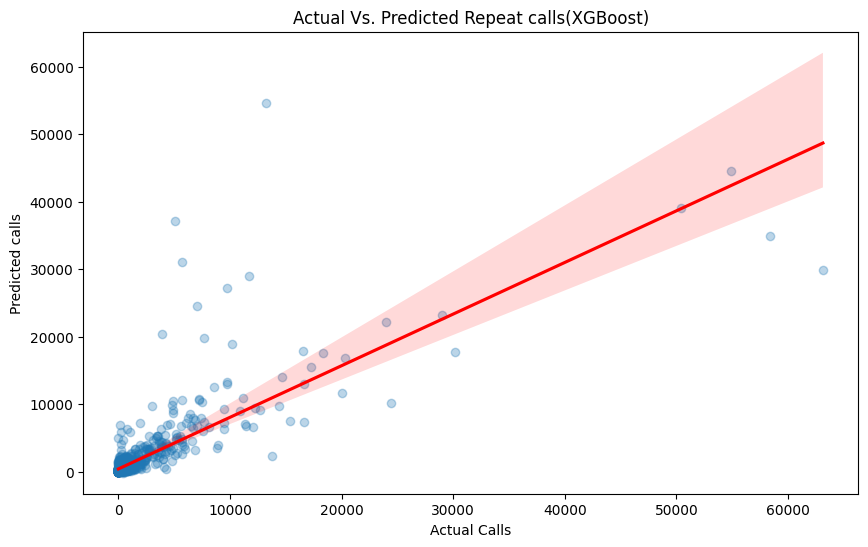

In [124]:
plt.figure(figsize=(10,6))
sns.regplot(x=y_test, y=xgb_pred, scatter_kws={'alpha':0.3}, line_kws= {'color':'red'})
plt.title('Actual Vs. Predicted Repeat calls(XGBoost)')
plt.xlabel('Actual Calls')
plt.ylabel('Predicted calls')
plt.show()

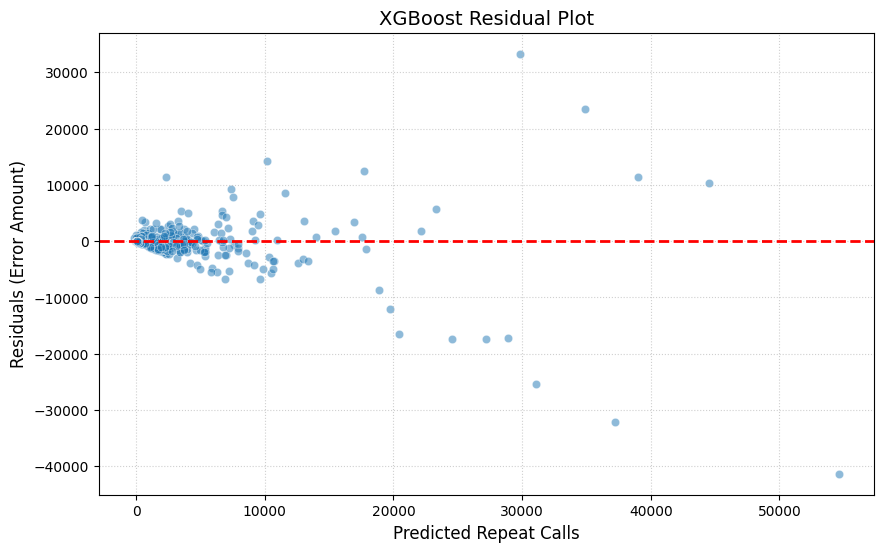

In [125]:
residuals = y_test -xgb_pred
plt.figure(figsize=(10,6))
sns.scatterplot(x=xgb_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('XGBoost Residual Plot', fontsize=14)
plt.xlabel('Predicted Repeat Calls', fontsize=12)
plt.ylabel('Residuals (Error Amount)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
          


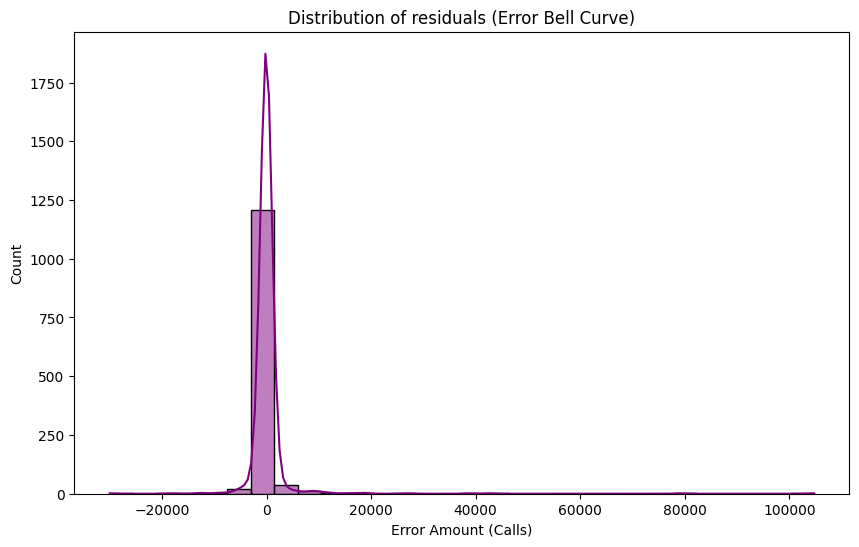

In [103]:
plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.title('Distribution of residuals (Error Bell Curve)')
plt.xlabel('Error Amount (Calls)')
plt.show()

In [104]:
## look for outlier
test_indices = X_test.index
outlier_analysis = df.loc[test_indices].copy()

outlier_analysis['Predicted_Calls'] = xgb_pred
outlier_analysis['Absolute_Error'] = np.abs(outlier_analysis['total_repeat_issue_calls'] - xgb_pred)

top_outliers = outlier_analysis.sort_values(by='Absolute_Error', ascending=False).head(5)
print("---TOP 5 data outlier---")
print(top_outliers[['Month_num', 'analytic_business_unit', 'primary_reason', 
                    'total_repeat_issue_calls', 'Predicted_Calls', 'Absolute_Error']])

---TOP 5 data outlier---
      Month_num analytic_business_unit             primary_reason  \
1726          9        LargeAppliances      Order Delivery->Delay   
1553          9        LargeAppliances  Returns ->Customer Return   
5520          2    EmergingElectronics  Returns ->Customer Return   
6067          1    EmergingElectronics      Order Delivery->Delay   
2825          7           DigitalCombo  Returns ->Customer Return   

      total_repeat_issue_calls  Predicted_Calls  Absolute_Error  
1726                  248644.0    143878.750000   104765.250000  
1553                  136253.0     57360.414062    78892.585938  
5520                   98523.0     55770.601562    42752.398438  
6067                   48184.0      9774.213867    38409.786133  
2825                   13256.0     43268.253906    30012.253906  


In [ ]:
df_clean = df[df['risk